In [1]:
import torch
import os.path
import argparse
import urllib.request

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from data import *
from utils import *
from PIL import Image
from datetime import datetime
from sklearn.mixture import GaussianMixture as GMM
from sklearn.model_selection import train_test_split

In [ ]:
parser = argparse.ArgumentParser(description='Gen-RKM Model')

parser.add_argument('--N', type=int, default=100, help='Total # of samples')
parser.add_argument('--mb_size', type=int, default=100, help='Mini-batch size. See utils.py')
parser.add_argument('--h_dim', type=int, default=10, help='Dim of latent vector')
parser.add_argument('--capacity', type=int, default=32, help='Capacity of network. See utils.py')
parser.add_argument('--x_fdim', type=int, default=128, help='Input x_fdim. See utils.py')
parser.add_argument('--y_fdim', type=int, default=20, help='Input y_fdim. See utils.py')
parser.add_argument('--c_accu', type=float, default=100, help='Input weight on recons_error')

parser.add_argument('--lr', type=float, default=1e-4, help='Input learning rate for optimizer')
parser.add_argument('--max_epochs', type=int, default=5000, help='Input max_epoch for cut-off')
parser.add_argument('--device', type=str, default='cpu', help='Device type: cuda or cpu')
parser.add_argument('--workers', type=int, default=0, help='# of workers for dataloader')
parser.add_argument('--shuffle', type=bool, default=False, help='shuffle dataset: true or false')

opt, _ = parser.parse_known_args()

In [3]:
xtrain, ipVec_dim, nChannels = get_mmcelebahq_dataloader(args=opt)

/Users/arthurclarysse/Desktop/🎓/03 Masterproef CS/VUB-MT-Development/Models/GenRKM-MMCelebHQ-V3/data.py:28: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4424.)
  label = torch.tensor(label, dtype=torch.double).T


In [4]:
ct = time.strftime("%Y%m%d-%H%M")
dirs = create_dirs(ct=ct)
dirs.create()

In [ ]:
def kPCA(X, Y, Z, eps=1e-6):
    # Kernel matrix (B,B)
    a = X @ X.T + Y @ Y.T + Z @ Z.T
    B = a.size(0)

    # Centering (same dtype/device as a)
    oneN = torch.ones(B, B, device=a.device, dtype=a.dtype) / B
    a = a - oneN @ a - a @ oneN + oneN @ a @ oneN

    # Force symmetry (numerical)
    a = 0.5 * (a + a.T)

    # Add small jitter to diagonal for conditioning
    a = a + eps * torch.eye(B, device=a.device, dtype=a.dtype)

    # Eigen-decomposition (ascending eigenvalues)
    evals, evecs = torch.linalg.eigh(a)

    # Sort descending
    idx = torch.argsort(evals, descending=True)
    evals = evals[idx]
    evecs = evecs[:, idx]

    # Return top components
    h = evecs[:, :h_dim]
    s = evals  # (B,)
    return h, s

In [6]:
# Energy function
def my_loss(output_im, data_im, output_sk, data_sk, output_la, data_la):
    h, s = kPCA(output_im, output_sk, output_la)

    U = torch.mm(torch.t(output_im), h)
    V = torch.mm(torch.t(output_sk), h)
    W = torch.mm(torch.t(output_la), h)

    x_im_tilde = net_im_de(torch.mm(h, torch.t(U)))
    x_sk_tilde = net_sk_de(torch.mm(h, torch.t(V)))
    x_la_tilde = net_la_de(torch.mm(h, torch.t(W)))

    # cost
    f1 = torch.trace(torch.mm(torch.mm(output_im, U), torch.t(h))) + torch.trace(torch.mm(torch.mm(output_sk, V), torch.t(h))) + torch.trace(torch.mm(torch.mm(output_la, W), torch.t(h)))
    f2 = 0.5 * torch.trace(torch.mm(h, torch.mm(torch.diag(s[:h_dim]), torch.t(h))))
    f3 = 0.5 * ((torch.trace(torch.mm(torch.t(U), U))) + (torch.trace(torch.mm(torch.t(V), V))) + (torch.trace(torch.mm(torch.t(W), W))))
    
    recon_loss1 = torch.nn.MSELoss()
    recon_loss2 = torch.nn.MSELoss()
    recon_loss3 = torch.nn.MSELoss()
    f4 = recon_loss1(x_im_tilde.view(-1, 49152), data_im.view(-1, 49152)) + recon_loss2(x_sk_tilde.view(-1, 16384), data_sk.view(-1, 16384)) + recon_loss3(x_la_tilde.view(-1, 40), data_la.view(-1, 40))  # reconstruction loss

    loss = - f1 + f3 + f2 + 0.5 * (- f1 + f3 + f2) ** 2 + 100 * f4
    return loss

In [ ]:
net_im_en = NetImEn().double().to(opt.device)
net_sk_en = NetSkEn().double().to(opt.device)
net_la_en = NetLaEn().double().to(opt.device)

net_im_de = NetImDe().double().to(opt.device)
net_sk_de = NetSkDe().double().to(opt.device)
net_la_de = NetLaDe().double().to(opt.device)

In [8]:
params = list(net_im_en.parameters()) + list(net_sk_en.parameters()) + list(net_la_en.parameters()) + list(net_im_de.parameters()) + list(net_sk_de.parameters()) + list(net_la_de.parameters())
optimizer = torch.optim.Adam(params, lr=learning_rate, weight_decay=0)

l_cost = 6  # Costs from where checkpoints will be saved
t = 1
cost = np.inf  # Initialize cost

In [9]:
while cost > 0.2 and t <= opt.max_epochs:  # run epochs until convergence
    permutation = torch.randperm(opt.N)
    avg_loss = 0
    for i, (data_im, data_sk, data_la) in enumerate(xtrain):
        # indices = permutation[i:i + mb_size]

        data_im = data_im.to(opt.device)
        data_sk = data_sk.to(opt.device)
        data_la = data_la.to(opt.device)
        
        output_im = net_im_en(data_im)
        output_sk = net_sk_en(data_sk)
        output_la = net_la_en(data_la)

        loss = my_loss(output_im, data_im, output_sk, data_sk, output_la, data_la)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        avg_loss += loss.detach().cpu().numpy()
        
    cost = avg_loss

    # Remember lowest cost and save checkpoint
    is_best = cost < l_cost
    l_cost = min(cost, l_cost)
    dirs.save_checkpoint({
        'epochs': t + 1,
        'net_im_en_state_dict': net_im_en.state_dict(),
        'net_sk_en_state_dict': net_sk_en.state_dict(),
        'net_la_en_state_dict': net_la_en.state_dict(),

        'net_im_de_state_dict': net_im_de.state_dict(),
        'net_sk_de_state_dict': net_sk_de.state_dict(),
        'net_la_de_state_dict': net_la_de.state_dict(),

        'l_cost': l_cost,
        'optimizer': optimizer.state_dict()}, is_best)

    print(t, cost)
    t += 1
print('Finished Training. Lowest cost: {}'.format(l_cost))

1 51.397021998461
2 51.311804573336374
3 51.22613693439916
4 51.14371719304346
5 51.06018963893211
6 50.97854445037689
7 50.898373353042025
8 50.81940826617589
9 50.740336781823586
10 50.658537644517764
11 50.57475200703773
12 50.48848142444733
13 50.39588616536647
14 50.29624776908212
15 50.18724696577415
16 50.06650274065474
17 49.93144066865469
18 49.779069301677204
19 49.605493011830035
20 49.40662049062439
21 49.1784629954072
22 48.91700599368943
23 48.618201897488014
24 48.280556360911866
25 47.89981670622812
26 47.47414226220784
27 47.0048857136006
28 46.493577851826956
29 45.945001510832306
30 45.362742913458845
31 44.75380619367009
32 44.12837389105174
33 43.50523542091322
34 42.88596239915148
35 42.28216092859663
36 41.69356472140361
37 41.152350180810046
38 40.59008431895748
39 40.051314943946466
40 39.533059962146254
41 39.06176753502859
42 38.71048607841617
43 38.516698861169615
44 38.315220544151146
45 38.04620086720411
46 37.781440898665856
47 37.57962328681771
48 37.438

In [10]:
# Get latest model
if os.path.exists('cp/{}'.format(dirs.dircp)):
    sd_mdl = torch.load('cp/{}'.format(dirs.dircp), weights_only=False)
    net_im_en.load_state_dict(sd_mdl['net_im_en_state_dict'])
    net_sk_en.load_state_dict(sd_mdl['net_sk_en_state_dict'])
    net_la_en.load_state_dict(sd_mdl['net_la_en_state_dict'])

    net_im_de.load_state_dict(sd_mdl['net_im_de_state_dict'])
    net_sk_de.load_state_dict(sd_mdl['net_sk_de_state_dict'])
    net_la_de.load_state_dict(sd_mdl['net_la_de_state_dict'])

U, V, W, h, s = mmcelebahq_final_compute(opt, net_im_en, net_sk_en, net_la_en, kPCA)

100


In [11]:
# Save Model
torch.save({'net_im_en': net_im_en,
            'net_sk_en': net_sk_en,
            'net_la_en': net_la_en,

            'net_im_de': net_im_de,
            'net_sk_de': net_sk_de,
            'net_la_de': net_la_de,


            'net_im_en_state_dict': net_im_en.state_dict(),
            'net_sk_en_state_dict': net_sk_en.state_dict(),
            'net_la_en_state_dict': net_la_en.state_dict(),

            'net_im_de_state_dict': net_im_de.state_dict(),
            'net_sk_de_state_dict': net_sk_de.state_dict(),
            'net_la_de_state_dict': net_la_de.state_dict(),

            'data_im': data_im,
            'data_sk': data_sk,
            'data_la': data_la,
            'classes': get_classes(),
            'h': h, 'N': N, 's': s, 'U': U, 'V': V}, 'out/{}'.format(dirs.dirout))

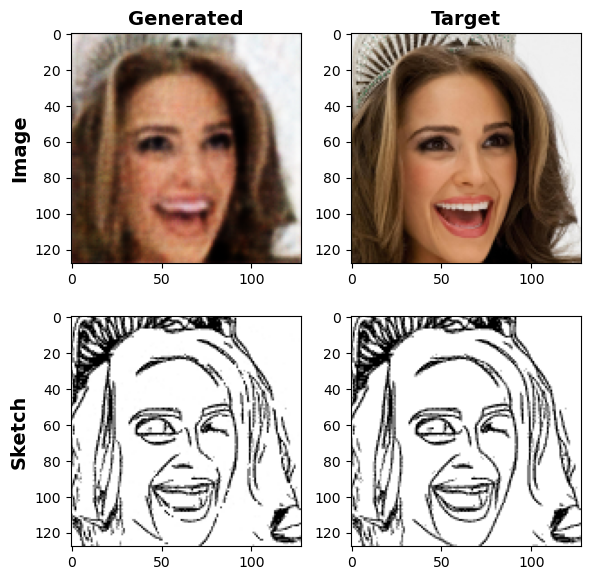

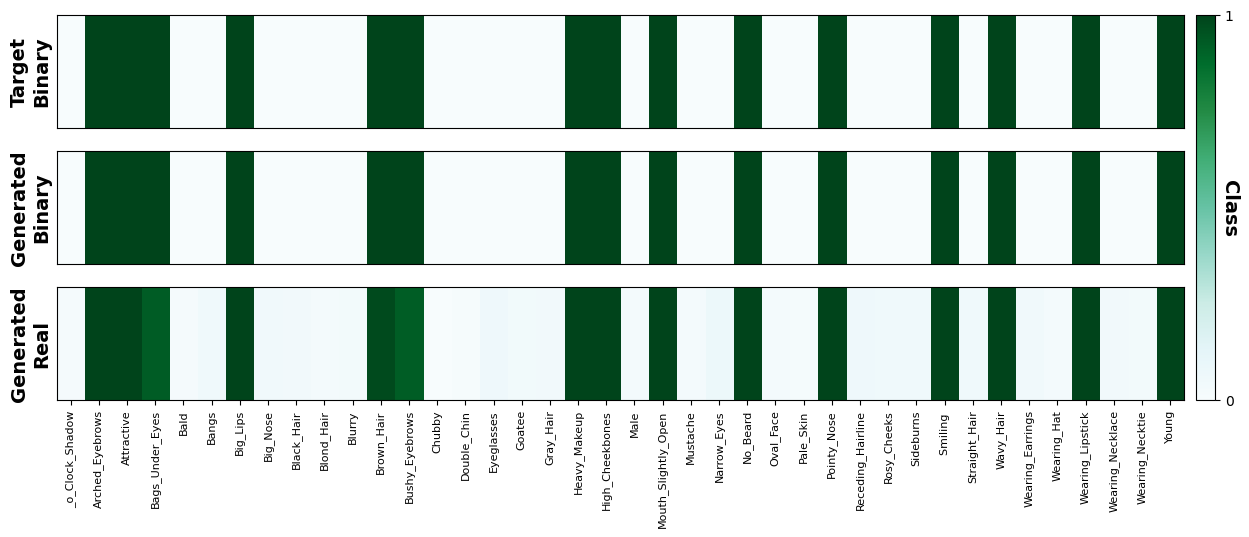

In [ ]:
target_index = 0
h_target = h[target_index, :]

# Generate Image
z_im = torch.mv(U, h_target).unsqueeze(0)
im_gen = net_im_de(z_im).detach().cpu().numpy()
im_gen = im_gen.reshape(3, 128, 128).transpose(1, 2, 0)

# Generate Sketch
z_sk = torch.mv(V, h_target).unsqueeze(0)
sk_gen = net_sk_de(z_sk).detach().cpu().numpy()
sk_gen = sk_gen.reshape(128, 128).transpose(0,1)#, 1)#.transpose(1, 2, 0)

# Generate Labels
la_gen = net_la_de(torch.mv(W, h_target)).detach().cpu().numpy()

# Plot Image + Sketch
fig, ax = plt.subplots(2, 2, figsize=(6, 6))

ax[0,0].imshow(im_gen)
ax[0,0].set_title('Generated', size=14, weight='bold')
ax[0,0].set_ylabel('Image', rotation=90, size=14, weight='bold')

ax[1,0].imshow(sk_gen, cmap='gray')
ax[1,0].set_ylabel('Sketch', rotation=90, size=14, weight='bold')

ax[0,1].imshow(data_im[target_index].numpy().transpose(1, 2, 0))
ax[0,1].set_title('Target', size=14, weight='bold')

ax[1,1].imshow(data_sk[target_index].numpy().transpose(1, 2, 0), cmap='gray')

plt.tight_layout()
plt.show()

# Plot Labels
fig, ax = plt.subplots(3, 1, figsize=(15, 5))
ax[0].imshow(data_la[target_index].numpy().reshape(1, -1), cmap='BuGn', aspect='auto')
ax[0].set_yticks([])
ax[0].set_xticks([])
ax[0].set_ylabel('Target\nBinary', rotation=90, size=14, weight='bold')

ax[1].imshow((la_gen.reshape(1, -1) > 0.5).astype(np.int64), cmap='BuGn', aspect='auto')
ax[1].set_yticks([])
ax[1].set_xticks([])
ax[1].set_ylabel('Generated\nBinary', rotation=90, size=14, weight='bold')

ax[2].imshow(la_gen.reshape(1, -1), cmap='BuGn', aspect='auto')
ax[2].set_yticks([])
ax[2].set_xticks(range(len(get_classes())))
ax[2].set_xticklabels(get_classes(), rotation=90, size=8)
ax[2].set_ylabel('Generated\nReal', rotation=90, size=14, weight='bold')

cbar = fig.colorbar(plt.cm.ScalarMappable(cmap='BuGn'), ax=ax, orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['0', '1'])
cbar.set_label('Class', rotation=270, size=14, weight='bold')
